# Laplace's equation

As an example of a multi-dimensional boundary value problem, let's try to solve Laplace's equation $$\nabla^2 V(\vec{r}) = 0$$ with either $V$ or $\vec{\nabla} V$ specified on the boundary. To keep things simple, we'll stick to Laplace's equation here, but it is straightforward to add a source term on the right-hand side if you need to solve Poisson's equation instead.

The first step is to finite-difference the equation. In 2D, with grid points labelled by $(i,j)$ this gives

$${V_{i+1,j}-2V_{i,j}+V_{i-1,j}\over h^2} + {V_{i,j+1}-2V_{i,j}+V_{i,j-1}\over h^2} = 0$$

where we set the grid spacing to $h$ in both directions for simplicity. Collecting terms,

$$V_{i+1,j}+V_{i-1,j} + V_{i,j+1}+V_{i,j-1}  -4V_{i,j}  = 0$$

or

$$V_{i,j} = {V_{i+1,j}+V_{i-1,j} + V_{i,j+1}+V_{i,j-1}\over 4}$$(laplace)

There are a few different ways we can try to solve this.

## Relaxation: Jacobi method

Equation {eq}`laplace` has a simple interpretation: $V_{i,j}$ is the average of $V$ on the neighbouring grid cells. This suggests a simple algorithm that we could use to relax to a solution from a starting guess:

$$V^{n+1}_{i,j} = {1\over 4}\left(V^n_{i+1,j}+V^n_{i-1,j} + V^n_{i,j+1}+V^n_{i,j-1}\right),$$

where $n$ labels the iteration. This known as the *Jacobi method*. In each iteration, we make a new grid of values $\{V^{n+1}_{i,j}\}$ that correspond to the average values of the neighbours in the old grid $\{V^n_{i,j}\}$.


As an example, let's solve the 2D potential around a circular conductor, with $V=1$ on the conductor and $V=0$ on the boundaries of the domain. Here is some code to get you going.

In [8]:
import numpy as np
from matplotlib import pyplot as plt
import time

In [9]:
def set_bcs(n):
    # Create a mask to set the boundary points
    # (following https://github.com/sievers/phys512-2022/tree/master/pdes )
    
    # create a 2D array filled with the value of r, distance from the center
    x = np.linspace(-1,1,n)
    xsqr = np.outer(x**2,np.ones(n))
    rsqr = xsqr+xsqr.T
    # this will be the size of the central circle
    R = 0.1
    
    # points in the mask that are True correspond to boundary points
    mask = np.zeros([n,n],dtype='bool')
    mask[rsqr<R**2] = True
    mask[:,0] = True
    mask[0,:] = True
    mask[-1,:] = True
    mask[:,-1] = True
    
    # bc contains the values of V in the boundary points
    bc = np.zeros([n,n])
    bc[rsqr < R**2] = 1.0

    return mask, bc

def laplace(mask, bc, niter, V, make_plot=True):
    # implements the Jacobi method to solve Laplace's equation

    # keep track of how much V changes from one iteration to the next
    deltaV = np.zeros(niter)
    
    t0 = time.time()
    for i in range(niter):
        # Jacobi update
        Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) + 
                       np.roll(V,1,1) + np.roll(V,-1,1))
        # Now reapply the boundary conditions
        Vnew[mask] = bc[mask]
        # Store how much V changed this iteration
        deltaV[i] = np.max(np.abs(Vnew-V))

        V = Vnew

        if (i+1)%100 == 0 and make_plot:
            n = len(V[0,:])
            plt.plot(np.arange(n), V[n//2,:])

    print('%d iterations took %lg seconds' %(niter, time.time()-t0))

    return V, deltaV

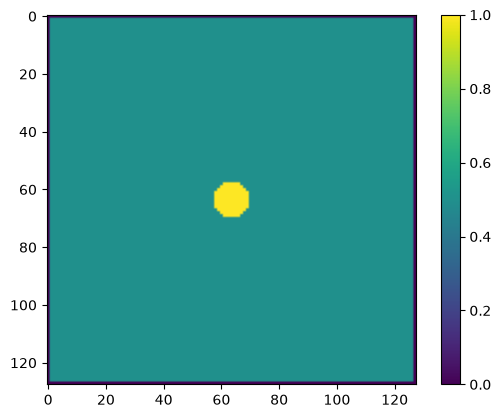

20 iterations took 0.00125313 seconds


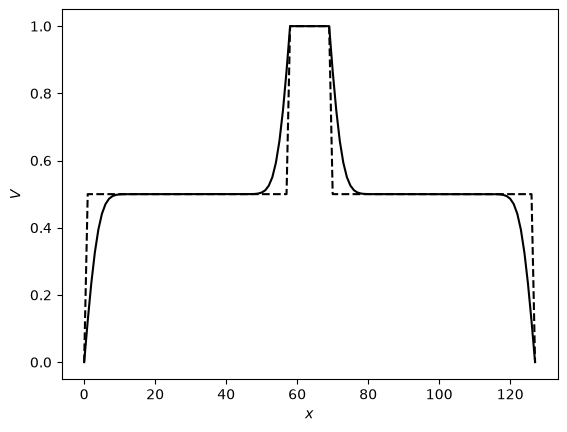

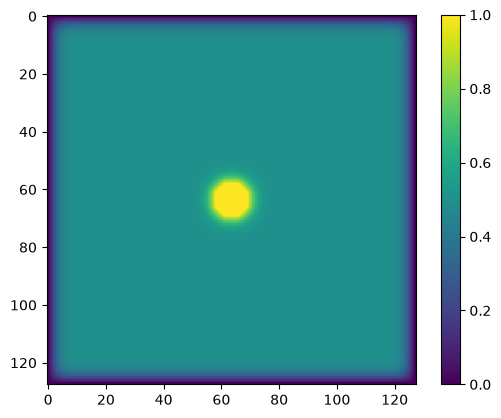

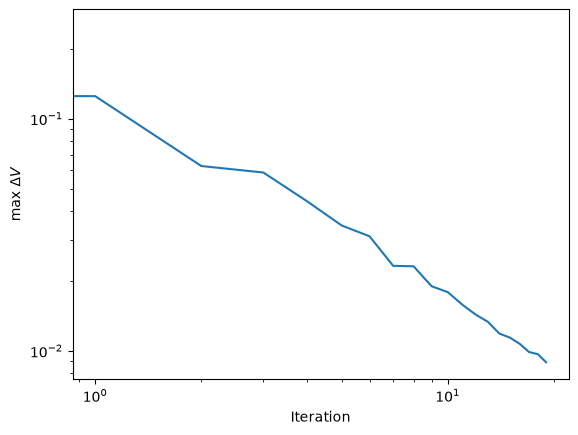

In [10]:
# Solve Laplace's equation with Jacobi method
n = 128
mask, bc = set_bcs(n)

# Initial guess for the potential 
V = np.zeros([n,n]) + 0.5
V[mask] = bc[mask]

plt.imshow(V)
plt.colorbar()
plt.show()
plt.clf()
plt.plot(np.arange(n), V[int(n/2),:], 'k--')
plt.ylabel(r'$V$')
plt.xlabel(r'$x$')

V_jacobi, deltaV_jacobi = laplace(mask, bc, 20, V)
    
plt.plot(np.arange(n), V_jacobi[int(n/2),:], 'k')
plt.show()

plt.clf()
plt.imshow(V_jacobi)
plt.colorbar()
plt.show()

plt.clf()
plt.plot(np.arange(len(deltaV_jacobi)), deltaV_jacobi)
plt.yscale('log')
plt.xscale('log')
plt.ylabel(r'max $\Delta V$')
plt.xlabel('Iteration')
plt.show()

:::{tip} Exercise

Try running this code and answer the following questions:

- How many iterations does it take before the solution has converged?
- How does the number of iterations needed for convergence scale with the number of grid points? Where does this scaling come from?
- How does the run time to convergence scale with the number of grid points?
:::

## Multigrid method

One way to try to speed up this kind of relaxation scheme is to use a set of grids with different resolutions. On a coarse grid with large spacing, the information from the boundaries can propagate quickly across the whole grid. This information can then be passed down to successively finer-spaced grids where the small scale structure is filled in. These methods are known as **multigrid**.

The following two functions take in a matrix and return a matrix with either half the size (`deres`) or twice the size (`upres`). There are many ways to do this (typically you would use some kind of interpolation depending on the problem), here we downscale by replacing each set of 4 pixels by a single pixel with the maximum value of the 4, and we upscale by copying each pixel 4 times.

In [4]:
# A simple way to decrease or increase the number of grid points by a factor of 2
# From https://github.com/sievers/phys512-2022/tree/master/pdes

def deres(map):
    tmp = np.maximum(map[::2,::2],map[1::2,::2])
    tmp = np.maximum(tmp,map[::2,1::2])
    tmp = np.maximum(tmp,map[1::2,1::2])
    return tmp

def upres(map):
    n = map.shape[0]
    tmp = np.zeros([2*n,2*n])
    tmp[::2,::2] = map
    tmp[1::2,::2] = map
    tmp[::2,1::2] = map
    tmp[1::2,1::2] = map
    return tmp

In [5]:
# Visualize matrices as a color map
def plot_matrices(A, titles=[], nmax=4):
    n = len(A)
    if titles==[]:
        titles = [""]*n
    if n>nmax:
        nx = nmax
    else:
        nx = n
    for j in range(int(np.floor(n/nmax))+1):        
        plt.clf()
        plt.figure(figsize=(nx*4,4))
        jmax = nmax*(j+1)
        if jmax > n:
            jmax = n
        for i,AA in enumerate(A[nmax*j:jmax]):
            plt.subplot(1, nx, i+1)
            plt.imshow(AA)
            plt.colorbar()
            plt.title(titles[nmax*j + i])
        plt.show()

<Figure size 640x480 with 0 Axes>

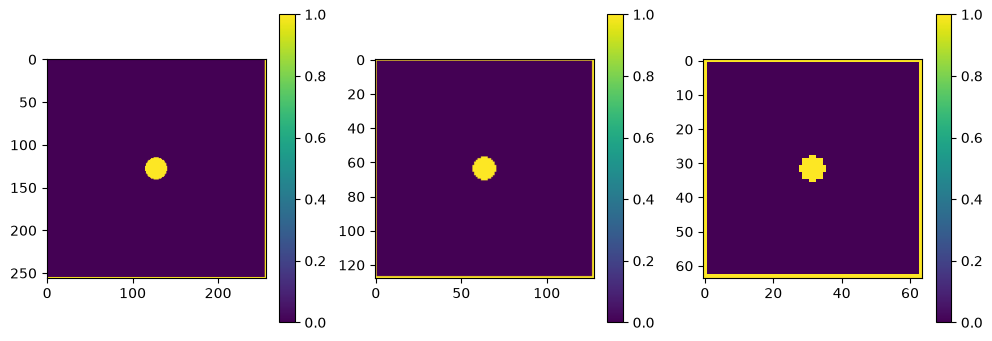

<Figure size 640x480 with 0 Axes>

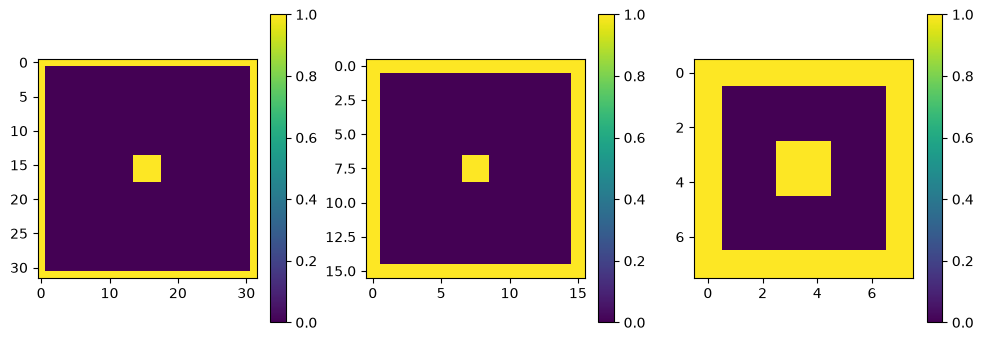

<Figure size 640x480 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

In [6]:
# Let's run a quick test of these functions

# Start with the initial condition from the Laplace problem above 
# and deres a number of times

n = 256
mask, bc = set_bcs(n)

masks = [mask,]

for i in range(1,6):
    masks.append(deres(masks[i-1]))

plot_matrices(masks, nmax=3)

:::{tip} Exercise
Use the `deres` and `upres` functions to solve the Laplace problem we looked at above with a multigrid method.

First use `deres` to make a coarse grid version of your problem. For example, if you start with $n=128$, then apply `deres` 3 times to create a $n=16$ version. Then run 100 iterations of the Jacobi method on the coarse grid. Use `upres` to convert the solution to $n=32$. Then run 100 Jacobi iterations on that, and use `upres` again to convert the solution to $n=64$. Repeat once more to get back to $n=128$.

What does this "preconditioned" $n=128$ solution look like? Use it as the starting point for your Jacobi method solution and compare its convergence properties with the solution without preconditioning.

Experiment with different numbers of steps and levels in the preconditioning to see how it affects the outcome.
:::

## Gauss-Seidel and successive over-relaxation

An alternative to the Jacobi method is the *Gauss-Siedel method* which involves changing the values of $V$ in place rather than creating an entirely new array. This means that as you go through the grid to compute averages, some of the values used will have already been updated. According to *Numerical Recipes* (section 19.5), this should converge two times faster than the Jacobi method.

An implementation of Gauss-Seidel that is amenable to vector operations is a checkerboard method. This uses the fact that the update for a given cell depends only on the up, down, left and right neighbours. We divide the grid into two just like the white and black squares on a chess board. First update the black squares based on the current values of the white ones, then update the white squares using the new values of the black ones.

Here is one way to do this using masks in python:

``` python
# create masks for the Gauss-Seidel chess board
even = (np.indices(V.shape).sum(axis=0) % 2 == 0) # True for black squares
odd = ~even  # True for white squares
# remove the boundary points from these masks so the boundaries don't update
even &= ~mask
odd &= ~mask
```

and then for the update:
```python
Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) 
               + np.roll(V,1,1) + np.roll(V,-1,1))
V[even] = Vnew[even]            
Vnew = 0.25 * (np.roll(V,1,0) + np.roll(V,-1,0) 
               + np.roll(V,1,1) + np.roll(V,-1,1))
V[odd] = Vnew[odd]
```

:::{tip} Exercise
(a) Modify your code so that it has the option of using either Jacobian or Gauss-Seidel updates. Check the claim in *Numerical Recipes* that Gauss-Seidel converges a factor of 2 faster by finding the number of iterations you need to take to get to $\Delta V=10^{-8}$ for both methods.

(b) Once you have Gauss-Seidel working, you can try **over-relaxation**. Replace your Gauss-Seidel update with 

``` python
V[even] = (1-w)*V[even] + w*Vnew[even]            
```

and 

``` python
V[odd] = (1-w)*V[odd] + w*Vnew[odd]            
```

for a constant parameter `w`.

First confirm that if you choose `w>=2`, the method is unstable. Then try values of `w` between 1 and 2. What value of `w` gives you the fastest convergence? How many iterations do you need to get to $\Delta V=10^{-8}$? How does the run time compare with Jacobi and Gauss-Seidel?

:::

## Further reading

- Good places to look for more detailed discussion of multigrid methods are Numerical Recipes 19.6 and in [Mike Zingale's course](https://zingale.github.io/computational_astrophysics/elliptic_multigrid/multigrid/multigrid.html) at Stonybrook.